# Fase 2 — Limpieza e imputación

**Objetivo:** dejar los datos sin nulos y listos para crear features (Fase 3), sin hacer trampas.

**Imputar** = rellenar un valor ausente con una estimación razonable. ¿Por qué no borrar las filas
con nulos, que sería lo fácil?

1. En **train** perderíamos 177 de 891 filas (el 20%) solo por `Age` — demasiada información tirada.
2. En **test** es directamente **imposible**: Kaggle exige una predicción para los 418 pasajeros,
   tengan nulos o no. Así que necesitamos una estrategia de imputación sí o sí.

## La regla de oro: nada de *data leakage*

Todo valor que usemos para imputar (una mediana, una moda) se calcula **solo con train** y luego se
aplica a train y test. Analogía: el train es el material de estudio y el test es el examen. Si
calculas la mediana mirando también el examen, estás copiando — tu nota de práctica (validación)
saldrá inflada y no se corresponderá con la real.

Para respetar esta regla usaremos el patrón **fit/transform**:

- **fit (ajustar):** aprender los parámetros (medianas, modas) del train.
- **transform (transformar):** aplicarlos a cualquier conjunto.

scikit-learn hace exactamente esto con sus transformadores; en esta fase lo construimos **a mano**
(está en [`src/limpieza.py`](../src/limpieza.py)) para entender el mecanismo por dentro. Cuando en la
Fase 4 aparezca el `Pipeline` de sklearn, ya sabrás qué hace por debajo.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mismo estilo que en el notebook 01 (colores fijos por significado, rejilla discreta)
C_NO, C_SI, C_A, C_B = "#2a78d6", "#1baf7a", "#4a3aa7", "#eb6834"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": SECONDARY, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "Segoe UI", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.figsize": (7, 4),
})

train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")
print("train:", train.shape, "| test:", test.shape)

train: (891, 12) | test: (418, 11)


## 1 · Recordatorio: qué hay que arreglar

Del EDA (notebook 01) sabemos que los nulos son estos — y este es el plan para cada uno:

| Columna | Nulos | Estrategia |
|---|---|---|
| `Embarked` | 2 en train | Moda (valor más frecuente) |
| `Fare` | 1 en test | Mediana de su clase |
| `Age` | 177 train + 86 test | Mediana por grupo (título + clase) |
| `Cabin` | 687 train + 327 test | No se imputa: derivar `HasCabin` y eliminar |

Vamos una por una, de la más simple a la más delicada, mirando siempre **quiénes** son los afectados
antes de decidir. Un nulo no es solo un hueco: es un pasajero concreto.

## 2 · `Embarked`: 2 nulos en train

Antes de imputar a ciegas, miremos las dos filas. `train[train.Embarked.isna()]` filtra el DataFrame
quedándose con las filas donde la condición es True (esto se llama *boolean indexing* y lo usarás
constantemente en pandas).

In [2]:
train[train["Embarked"].isna()][["PassengerId", "Name", "Sex", "Pclass", "Ticket", "Fare", "Cabin"]]

,PassengerId,Name,Sex,Pclass,Ticket,Fare,Cabin
61,62,"Icard, Miss. Amelie",female,1,113572,80.0,B28
829,830,"Stone, Mrs. George Nelson (Martha Evelyn)",female,1,113572,80.0,B28


Fíjate qué caso más curioso: **misma clase (1ª), mismo billete (113572), mismo camarote (B28),
mismo fare (80£)** — son la Sra. Martha Stone y su doncella Amélie Icard, que viajaban juntas.
(Dato histórico: embarcaron en Southampton, así que la imputación que vamos a hacer acierta de pleno.)

La **moda** es el valor más frecuente de la columna. Con solo 2 casos entre 891, cualquier estrategia
sofisticada sería matar moscas a cañonazos:

In [3]:
print(train["Embarked"].value_counts())
print("\nModa:", train["Embarked"].mode()[0])

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Moda: S


**Decisión:** imputar `S` (Southampton), que además de la moda (644 de 889) resulta ser el
puerto real de estas dos pasajeras.

## 3 · `Fare`: 1 nulo en test

Mismo procedimiento: primero, ¿quién es?

In [4]:
test[test["Fare"].isna()][["PassengerId", "Name", "Sex", "Pclass", "Age", "Ticket", "Embarked"]]

,PassengerId,Name,Sex,Pclass,Age,Ticket,Embarked
152,1044,"Storey, Mr. Thomas",male,3,60.5,3701,S


El Sr. Thomas Storey, 60 años, 3ª clase. ¿Qué fare le ponemos? Aquí hay dos decisiones que
razonar, y las dos salen del EDA:

1. **¿Mediana o media?** Mediana. Vimos que `Fare` tiene una cola larguísima a la derecha (billetes
   de hasta 512£): la media (32£) está inflada por esos extremos; la mediana (14£) representa mejor
   al pasajero típico.
2. **¿Global o por grupo?** Por clase. El precio depende muchísimo de la clase — mira la diferencia:

In [5]:
print("Mediana de Fare por clase (train):")
print(train.groupby("Pclass")["Fare"].median().round(2))
print("\nMediana global:", train["Fare"].median())

Mediana de Fare por clase (train):
Pclass
1    60.29
2    14.25
3     8.05
Name: Fare, dtype: float64

Mediana global: 14.4542


Ponerle al Sr. Storey (3ª clase) la mediana global (14.45£) sería asignarle un precio típico de
**2ª** clase. La mediana de su clase, **8.05£**, es la estimación honesta.

> Patrón general que conviene interiorizar: **imputar condicionando en las variables que más
> influyen en la columna a rellenar**. Es el mismo argumento que usaremos ahora con `Age`, donde
> de verdad importa.

## 4 · `Age`: los 263 nulos importantes

Aquí una mala imputación **destruye señal**. En el EDA vimos que la edad predice sobre todo en los
niños (0-10 años ≈ 59% de supervivencia). La imputación perezosa — mediana global, 28 años — le
pondría 28 años a *todos* los nulos... incluidos los niños cuya edad no se registró. Adiós señal.

**Idea:** el título del nombre ya nos dice, aproximadamente, la edad. `Master` era el tratamiento
para **niños varones**; `Miss` para mujeres solteras (más jóvenes que las `Mrs` casadas). Extraemos
el título (adelantamos aquí una feature de la Fase 3 porque la necesitamos ya) y comprobamos si la
hipótesis se sostiene:

In [6]:
import sys
sys.path.append("../src")          # para poder importar nuestro modulo desde notebooks/
import limpieza

titulo = limpieza.extraer_titulo(train["Name"])
tabla = train.assign(Title=titulo).groupby("Title")["Age"].agg(["count", "median"])
tabla.columns = ["edades_conocidas", "mediana_edad"]
print(tabla)

        edades_conocidas  mediana_edad
Title                                 
Master                36           3.5
Miss                 146          21.0
Mr                   398          30.0
Mrs                  108          35.0
Rare                  26          44.5


Se sostiene de sobra: **`Master` → 3.5 años** (¡niños!), `Miss` → 21, `Mr` → 30, `Mrs` → 35,
`Rare` → 44.5. Imputar por título preserva a los niños que la mediana global borraría.

¿Podemos afinar más? Sí: dentro de un mismo título, la edad también varía con la **clase**
(los pasajeros de 1ª eran mayores — la riqueza suele llegar con la edad):

In [7]:
print(train.assign(Title=titulo).groupby(["Title", "Pclass"])["Age"].median().unstack().round(1))

Pclass     1     2     3
Title                   
Master   4.0   1.0   4.0
Miss    30.0  24.0  18.0
Mr      40.0  31.0  26.0
Mrs     41.5  32.0  31.0
Rare    45.0  42.0   NaN


Mira la fila `Mr`: mediana de **40 años en 1ª** frente a **26 en 3ª**. Merece la pena condicionar
en (título, clase) y no solo en título.

Pero ojo al `NaN` de `Rare` × 3ª clase: **en train no hay ninguna edad conocida para ese grupo**, así
que no existe mediana. Y podría pasar lo mismo con cualquier grupo al transformar el test. Por eso
nuestra imputación necesita una **cadena de respaldo** (*fallback*):

```
1º mediana de (Título, Clase)   ← lo más específico
2º mediana del Título           ← si el grupo no existía en train
3º mediana global del train     ← último recurso
```

## 5 · `Cabin` → `HasCabin`

Decidido ya en el EDA: con 77% de nulos no se puede imputar nada creíble. Derivamos la binaria
`HasCabin` (¿estaba registrado el camarote? → 67% vs 30% de supervivencia) y eliminamos la columna.

## 6 · Todo junto: el módulo `src/limpieza.py`

Todo lo que acabamos de razonar está empaquetado en [`src/limpieza.py`](../src/limpieza.py) — código
**reutilizable**: los notebooks de las fases siguientes lo importarán en una línea en vez de copiar
celdas. El módulo tiene tres piezas:

| Función | Papel | Patrón |
|---|---|---|
| `extraer_titulo(nombres)` | La regex del EDA, centralizada | — |
| `ajustar(train)` | Aprende medianas y modas **solo del train** y las devuelve en un diccionario | **fit** |
| `transformar(df, params)` | Aplica la limpieza a cualquier conjunto usando ese diccionario | **transform** |

Ábrelo y léelo — está comentado línea a línea. Ejecutemos el **fit** y veamos qué aprende:

In [8]:
params = limpieza.ajustar(train)

print("Parametros aprendidos del train:\n")
print("- moda_embarked:", params["moda_embarked"])
print("- edad_global:", params["edad_global"])
print("- fare_por_clase:", params["fare_por_clase"].round(2).to_dict())
print("- edad_por_titulo:", params["edad_por_titulo"].to_dict())
print("- edad_por_titulo_clase: (Serie con", len(params["edad_por_titulo_clase"]), "grupos, la de la tabla anterior)")

Parametros aprendidos del train:

- moda_embarked: S
- edad_global: 28.0
- fare_por_clase: {1: 60.29, 2: 14.25, 3: 8.05}
- edad_por_titulo: {'Master': 3.5, 'Miss': 21.0, 'Mr': 30.0, 'Mrs': 35.0, 'Rare': 44.5}
- edad_por_titulo_clase: (Serie con 14 grupos, la de la tabla anterior)


Y ahora el **transform** — el mismo para los dos conjuntos, con los mismos parámetros. Ni una
sola estadística sale del test:

In [9]:
train_limpio = limpieza.transformar(train, params)
test_limpio  = limpieza.transformar(test, params)

print("train_limpio:", train_limpio.shape, "| test_limpio:", test_limpio.shape)
train_limpio.head(3)

train_limpio:

 (891, 13) | test_limpio: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,0


## 7 · Verificación

Nunca te fíes de que una transformación "ha ido bien" — compruébalo. Tres controles:

1. **¿Quedan nulos?** Debería quedar exactamente cero en ambos conjuntos.
2. **¿Se conservan las filas?** Mismas filas que al principio (aquí no borramos nada).
3. **¿La imputación distorsiona la distribución?** Comparamos visualmente tres escenarios de `Age`.

In [10]:
print("Nulos restantes en train_limpio:", train_limpio.isna().sum().sum())
print("Nulos restantes en test_limpio :", test_limpio.isna().sum().sum())
print("Filas: train", len(train_limpio), "de", len(train), "| test", len(test_limpio), "de", len(test))
print("Columnas nuevas:", [c for c in train_limpio.columns if c not in train.columns],
      "| eliminadas:", [c for c in train.columns if c not in train_limpio.columns])

Nulos restantes en train_limpio: 0
Nulos restantes en test_limpio : 0
Filas: train 891 de 891 | test 418 de 418
Columnas nuevas: ['Title', 'HasCabin'] | eliminadas: ['Cabin']


Cero nulos, mismas filas, `Title` y `HasCabin` añadidas, `Cabin` fuera. ✔

Ahora el control visual. Comparamos la distribución de edad en tres versiones:

- **Original**: solo las 714 edades conocidas (la referencia).
- **Imputación ingenua**: los 177 nulos rellenados con la mediana global (28) — lo que NO hicimos.
- **Nuestra imputación**: por (título, clase).

Si la imputación es razonable, la forma de la distribución debe parecerse a la original.

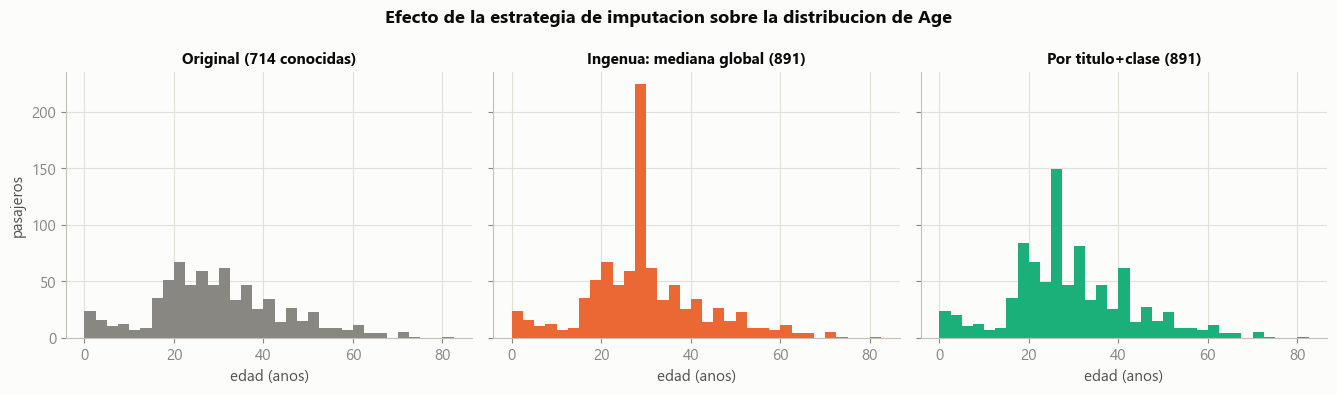

In [11]:
ingenua = train["Age"].fillna(train["Age"].median())

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True, sharex=True)
bins = np.arange(0, 85, 2.5)
for ax, datos, titulo_g, color in [
    (axes[0], train["Age"].dropna(), "Original (714 conocidas)", MUTED),
    (axes[1], ingenua, "Ingenua: mediana global (891)", C_B),
    (axes[2], train_limpio["Age"], "Por titulo+clase (891)", C_SI),
]:
    ax.hist(datos, bins=bins, color=color)
    ax.set_title(titulo_g, fontsize=11); ax.set_xlabel("edad (anos)")
axes[0].set_ylabel("pasajeros")
fig.suptitle("Efecto de la estrategia de imputacion sobre la distribucion de Age", fontweight="bold")
plt.tight_layout()
plt.show()

**Lo que hay que ver ahí:** en la versión *ingenua* (centro) aparece un rascacielos artificial
en 28 años — 177 personas convertidas de golpe en veintiochoañeros, niños incluidos. Nuestra versión
(derecha) también añade barras (es inevitable, estamos inventando 177 valores), pero **las reparte**
entre las edades típicas de cada título y clase, respetando mucho mejor la forma original.

Un control más fino: ¿cuántos "niños" reconoce cada versión?

In [12]:
print("Pasajeros con edad <= 10 anos:")
print("- original (solo conocidas):", (train["Age"].dropna() <= 10).sum())
print("- imputacion ingenua       :", (ingenua <= 10).sum())
print("- por titulo+clase         :", (train_limpio["Age"] <= 10).sum())
maestros_sin_edad = (limpieza.extraer_titulo(train["Name"]) == "Master") & train["Age"].isna()
print("\nDe los", maestros_sin_edad.sum(), "'Master' sin edad, nuestra imputacion les asigna:")
print(train_limpio.loc[maestros_sin_edad, "Age"].value_counts().to_string())

Pasajeros con edad <= 10 anos:
- original (solo conocidas): 64
- imputacion ingenua       : 64
- por titulo+clase         : 68

De los 4 'Master' sin edad, nuestra imputacion les asigna:
Age
4.0    4


La ingenua deja los niños en 64 (los convierte en adultos de 28); la nuestra los sube — los
`Master` sin edad reciben ~4 años, que es lo que eran. La señal "niño → sobrevive" queda protegida.

## 8 · Guardar los datos limpios

Guardamos los dos conjuntos en `data/processed/` para que la Fase 3 arranque de aquí.
(`index=False` evita que pandas añada una columna extra con el número de fila.)

Nota: como la limpieza vive en `src/limpieza.py`, estos CSV son solo un atajo — siempre podemos
regenerarlos desde los datos crudos ejecutando este notebook.

In [13]:
import os
os.makedirs("../data/processed", exist_ok=True)
train_limpio.to_csv("../data/processed/train_limpio.csv", index=False)
test_limpio.to_csv("../data/processed/test_limpio.csv", index=False)
print("Guardado:", os.listdir("../data/processed"))

Guardado: ['test_limpio.csv', 'train_limpio.csv']


## 9 · Conclusiones de la Fase 2

- **Cero nulos** en train y test, sin borrar ni una fila.
- Cada imputación quedó **justificada por el EDA**: moda para 2 casos triviales de `Embarked`;
  mediana *de su clase* para el `Fare` del Sr. Storey; mediana por *(título, clase)* con cadena de
  respaldo para `Age`, protegiendo la señal de los niños; `Cabin` convertida en `HasCabin`.
- La regla anti-leakage quedó codificada en la estructura misma del código:
  `ajustar()` solo ve train; `transformar()` no calcula nada, solo aplica.
- Ya tenemos dos features nuevas de regalo (`Title`, `HasCabin`) y un módulo reutilizable.

**Siguiente — Fase 3 (ingeniería de características):** `FamilySize`, `IsAlone`, `TicketGroup`,
`FarePerPerson`, y la codificación de las categóricas (`Sex`, `Embarked`, `Title`) a números,
que es lo que los modelos necesitan para poder entrenar.